# Perfil Demográfico — Base SIAPE

Este notebook mostra **como o quadro de servidores está distribuído** em quatro
dimensões: idade, sexo, escolaridade e UF de exercício. Todos os números são
agregados (contagens e percentuais) — nenhum servidor é identificado individualmente.

Cada seção tem uma explicação em linguagem simples do que o gráfico mostra.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path("..").resolve()))
from src.viz_style import (
    COR_PRINCIPAL,
    COR_TEXTO_PRIMARIA,
    agrupar_celulas_pequenas,
    aplicar_estilo_global,
    estilizar_eixos,
    grafico_barra_horizontal,
    grafico_top_n_outros,
)

DATA_PATH = Path("../data/raw/DB_SIAPE_processado_20260729_v2.xlsx")
df = pd.read_excel(DATA_PATH, engine="openpyxl")

aplicar_estilo_global()
TOTAL = len(df)

## Distribuição por Idade

**O que este gráfico mostra**: quantos servidores existem em cada faixa de idade
(agrupados de 5 em 5 anos). Ajuda a visualizar se o quadro é, em média, mais jovem
ou mais próximo da aposentadoria.

In [2]:
resumo_idade = df["Idade"].describe()[["min", "mean", "50%", "max"]]
resumo_idade.index = ["Idade mínima", "Idade média", "Idade mediana", "Idade máxima"]
resumo_idade.round(1).to_frame(name="valor")

,valor
Idade mínima,18.0
Idade média,45.4
Idade mediana,44.0
Idade máxima,84.0


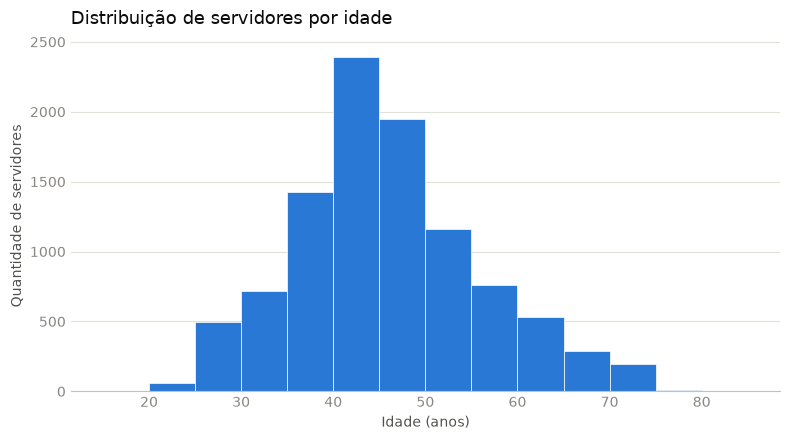

In [3]:
bins = range(15, int(df["Idade"].max()) + 6, 5)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df["Idade"], bins=list(bins), color=COR_PRINCIPAL, edgecolor="white", linewidth=0.5)
estilizar_eixos(ax, grade_y=True)
ax.set_title("Distribuição de servidores por idade", loc="left", fontsize=13, color=COR_TEXTO_PRIMARIA, pad=12)
ax.set_xlabel("Idade (anos)")
ax.set_ylabel("Quantidade de servidores")
plt.tight_layout()
plt.show()

## Distribuição por Sexo

**O que este gráfico mostra**: quantos servidores são do sexo feminino e quantos
são do sexo masculino, em número absoluto e em percentual.

In [4]:
contagem_sexo = df["Sexo"].value_counts()
percentual_sexo = (contagem_sexo / TOTAL * 100).round(1)
tabela_sexo = pd.DataFrame({"quantidade": contagem_sexo, "percentual": percentual_sexo})
tabela_sexo

,quantidade,percentual
Sexo,,
MASCULINO,5294,53.0
FEMININO,4697,47.0


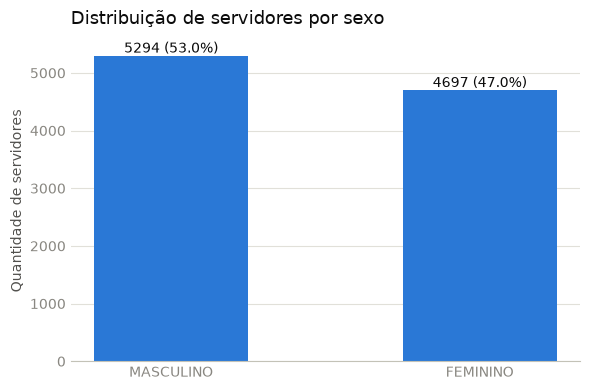

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
barras = ax.bar(contagem_sexo.index, contagem_sexo.values, color=COR_PRINCIPAL, width=0.5)
estilizar_eixos(ax, grade_y=True)
ax.set_title("Distribuição de servidores por sexo", loc="left", fontsize=13, color=COR_TEXTO_PRIMARIA, pad=12)
ax.set_ylabel("Quantidade de servidores")

for barra, pct in zip(barras, percentual_sexo.reindex(contagem_sexo.index)):
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2, altura,
        f"{int(altura)} ({pct}%)",
        ha="center", va="bottom", fontsize=10, color=COR_TEXTO_PRIMARIA,
    )

plt.tight_layout()
plt.show()

## Distribuição por Escolaridade

**O que este gráfico mostra**: o nível de escolaridade registrado dos servidores,
do mais comum para o menos comum.

**Nota de privacidade**: níveis de escolaridade com menos de 5 servidores são
agrupados em "Outras" — mostrar a contagem exata (ex: 1 pessoa) poderia identificar
um servidor específico.

In [6]:
contagem_escolaridade = df["Escolaridade"].value_counts()
contagem_escolaridade_protegida, rotulo_escolaridade_pequena = agrupar_celulas_pequenas(
    contagem_escolaridade, minimo=5
)

tabela_escolaridade = pd.DataFrame({
    "quantidade": contagem_escolaridade_protegida,
    "percentual": (contagem_escolaridade_protegida / TOTAL * 100).round(1),
})
tabela_escolaridade

,quantidade,percentual
ENSINO SUPERIOR,8467,84.7
MESTRADO,1165,11.7
DOUTORADO,357,3.6
"Outras (poucos casos, 2 categorias agrupadas)",2,0.0


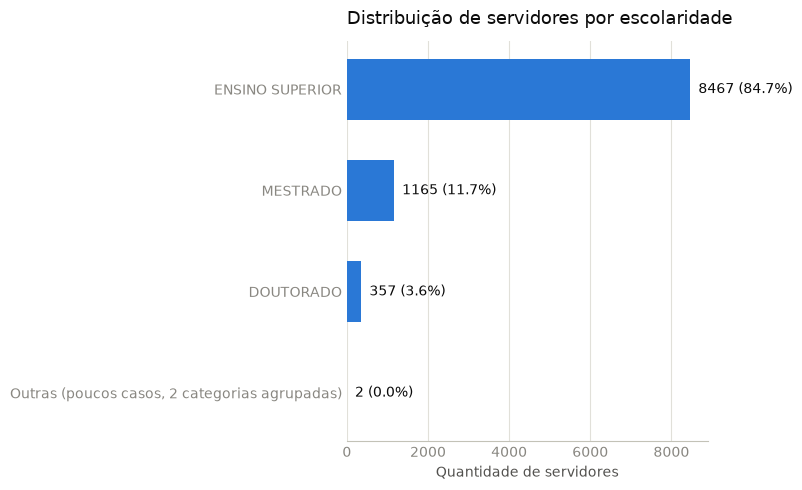

In [7]:
grafico_barra_horizontal(
    contagem_escolaridade_protegida, TOTAL, "Distribuição de servidores por escolaridade",
    destacar_neutro=rotulo_escolaridade_pequena,
)

## Distribuição por UF de exercício

**O que este gráfico mostra**: em quais estados (UF) os servidores estão lotados.
Para manter o gráfico legível, mostramos os 10 estados com mais servidores; o
restante aparece agrupado em cinza como "Outros" — sempre na base do gráfico,
para não ser confundido com um único estado grande.

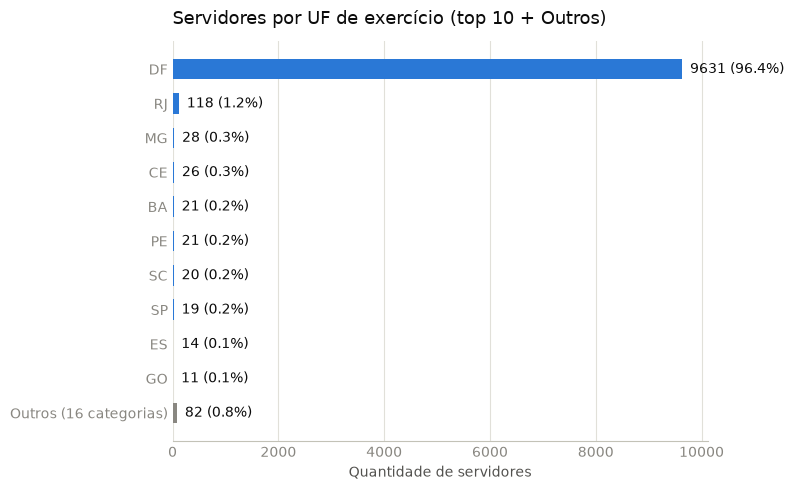

,quantidade,percentual
UF,,
DF,9631,96.4
RJ,118,1.2
MG,28,0.3
CE,26,0.3
PE,21,0.2
BA,21,0.2
SC,20,0.2
SP,19,0.2
ES,14,0.1


In [8]:
contagem_uf = grafico_top_n_outros(df["UF"], TOTAL, "Servidores por UF de exercício (top 10 + Outros)")

tabela_uf = pd.DataFrame({
    "quantidade": contagem_uf.head(10),
    "percentual": (contagem_uf.head(10) / TOTAL * 100).round(1),
})
tabela_uf

## Resumo consolidado

In [9]:
from IPython.display import Markdown, display

idade_media = df["Idade"].mean()
sexo_predominante = contagem_sexo.idxmax()
pct_sexo_predominante = percentual_sexo[sexo_predominante]
escolaridade_predominante = contagem_escolaridade.idxmax()
pct_escolaridade_predominante = round(contagem_escolaridade.max() / TOTAL * 100, 1)
uf_predominante = contagem_uf.idxmax()
pct_uf_predominante = round(contagem_uf.max() / TOTAL * 100, 1)

resumo_md = f"""
- A idade media dos servidores e de **{idade_media:.0f} anos**.
- O sexo predominante e **{sexo_predominante.lower()}**, representando **{pct_sexo_predominante}%** do total.
- O nivel de escolaridade mais comum e **{escolaridade_predominante.lower()}**, presente em **{pct_escolaridade_predominante}%** dos registros.
- O estado (UF) com mais servidores lotados e **{uf_predominante}**, concentrando **{pct_uf_predominante}%** do total.

Esses numeros descrevem o quadro como um todo — nenhum servidor especifico foi identificado nesta analise.
"""

display(Markdown(resumo_md))


- A idade media dos servidores e de **45 anos**.
- O sexo predominante e **masculino**, representando **53.0%** do total.
- O nivel de escolaridade mais comum e **ensino superior**, presente em **84.7%** dos registros.
- O estado (UF) com mais servidores lotados e **DF**, concentrando **96.4%** do total.

Esses numeros descrevem o quadro como um todo — nenhum servidor especifico foi identificado nesta analise.
